# Task 1 — Iris Flower Classification

**Oasis Infobyte Data Science Internship — OIBSIP**

Objective: classify Setosa, Versicolor and Virginica from physical measurements. This notebook covers every requested checklist item.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
sns.set_theme(style="whitegrid"); RANDOM_STATE=42

Matplotlib is building the font cache; this may take a moment.


## 1. Load dataset

In [2]:
iris=load_iris(as_frame=True)
df=iris.frame.copy(); df["species"]=df.target.map(dict(enumerate(iris.target_names))); df.drop(columns="target",inplace=True)
display(df.head()); print("Shape:",df.shape); print("\nDtypes:"); print(df.dtypes); print("\nNulls:"); print(df.isnull().sum()); display(df.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Shape: (150, 5)

Dtypes:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Nulls:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 2. EDA and visualizations

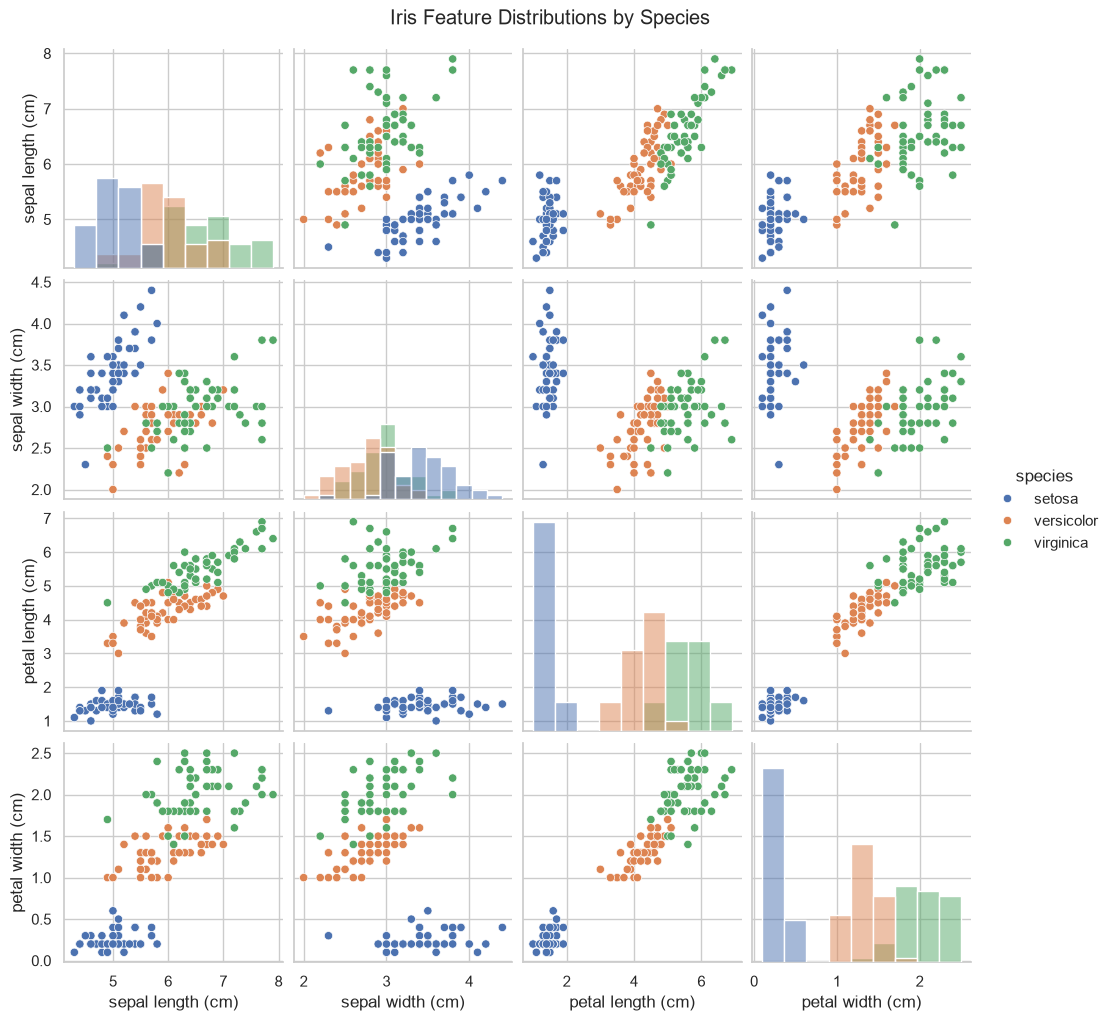

In [3]:
sns.pairplot(df,hue="species",diag_kind="hist"); plt.suptitle("Iris Feature Distributions by Species",y=1.02); plt.show()

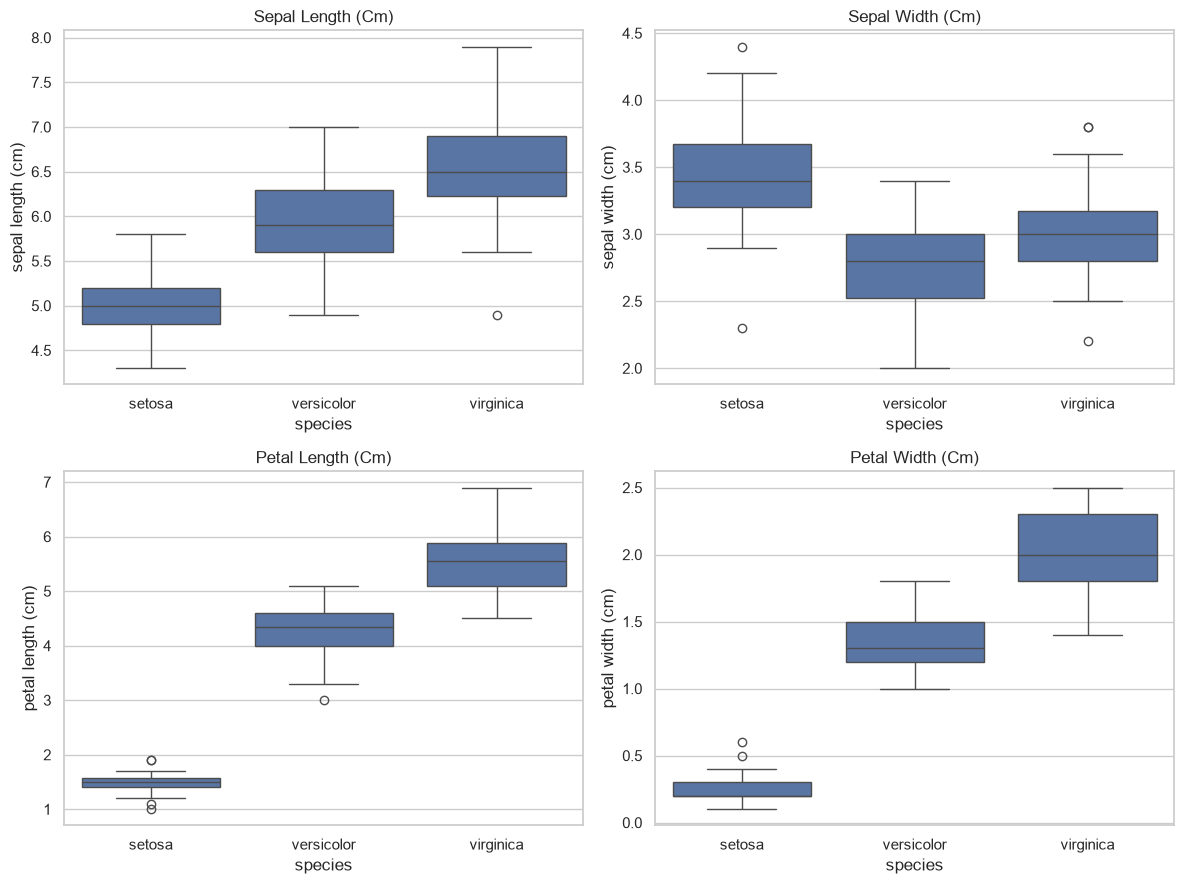

In [4]:
fig,axes=plt.subplots(2,2,figsize=(12,9))
for ax,f in zip(axes.ravel(),iris.feature_names): sns.boxplot(data=df,x="species",y=f,ax=ax); ax.set_title(f.title())
plt.tight_layout(); plt.show()

## 3. Feature selection discussion
Petal length and petal width are the most discriminative features because their distributions separate species more clearly. Sepal measurements overlap more, especially between Versicolor and Virginica. We retain all four features so the models use the complete original feature set.

In [5]:
X=df[iris.feature_names]; y=iris.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=RANDOM_STATE,stratify=y)

## 4. Train at least two classifiers

In [6]:
models={"Logistic Regression":Pipeline([("scale",StandardScaler()),("model",LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))]),"KNN":Pipeline([("scale",StandardScaler()),("model",KNeighborsClassifier(n_neighbors=5))]),"Random Forest":RandomForestClassifier(n_estimators=300,random_state=RANDOM_STATE)}
results={}
for name,m in models.items():
 m.fit(X_train,y_train); p=m.predict(X_test); results[name]=(m,p,accuracy_score(y_test,p))
comparison=pd.DataFrame({n:{"Accuracy":r[2]} for n,r in results.items()}).T.sort_values("Accuracy",ascending=False); display(comparison)

,Accuracy
Logistic Regression,0.933333
KNN,0.933333
Random Forest,0.900000


## 5. Evaluation

============================================================ Logistic Regression accuracy 0.9333
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.9000    0.9000    0.9000        10
   virginica     0.9000    0.9000    0.9000        10

    accuracy                         0.9333        30
   macro avg     0.9333    0.9333    0.9333        30
weighted avg     0.9333    0.9333    0.9333        30



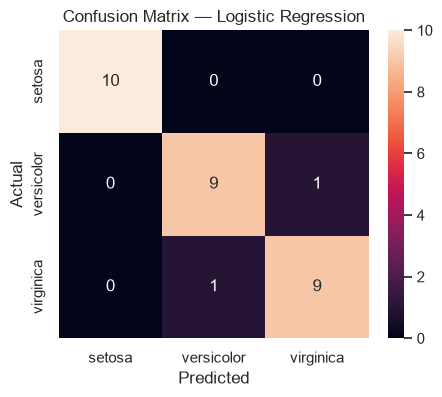

============================================================ KNN accuracy 0.9333
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8333    1.0000    0.9091        10
   virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30



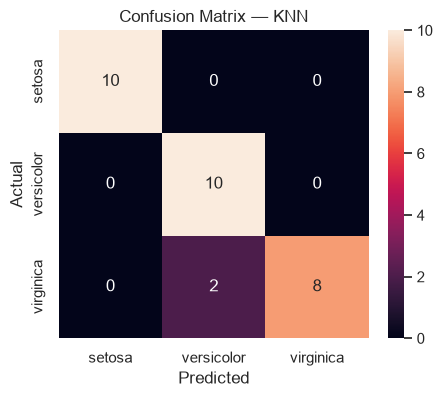

============================================================ Random Forest accuracy 0.9
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        10
  versicolor     0.8182    0.9000    0.8571        10
   virginica     0.8889    0.8000    0.8421        10

    accuracy                         0.9000        30
   macro avg     0.9024    0.9000    0.8997        30
weighted avg     0.9024    0.9000    0.8997        30



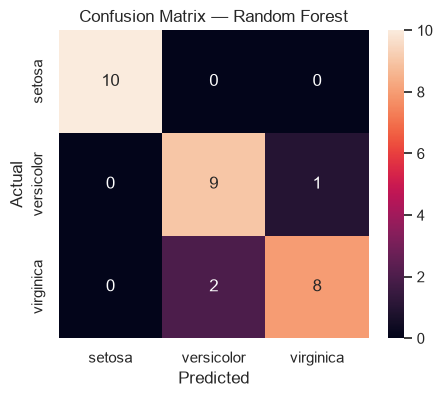

In [7]:
for name,(m,p,a) in results.items():
 print("="*60,name,"accuracy",round(a,4)); print(classification_report(y_test,p,target_names=iris.target_names,digits=4))
 cm=confusion_matrix(y_test,p); plt.figure(figsize=(5,4)); sns.heatmap(cm,annot=True,fmt="d",xticklabels=iris.target_names,yticklabels=iris.target_names); plt.title(f"Confusion Matrix — {name}"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

## 6. Best model

In [8]:
best=comparison.index[0]; print(f"Best-performing model: {best}"); print(f"Test accuracy: {comparison.loc[best,'Accuracy']:.4f}"); print("Justification: highest held-out test accuracy among evaluated classifiers.")

Best-performing model: Logistic Regression
Test accuracy: 0.9333
Justification: highest held-out test accuracy among evaluated classifiers.


## Final conclusion
The notebook includes built-in data loading, EDA, pairplot, boxplots, feature discussion, 80/20 split, three classifiers, accuracy, precision, recall, F1, confusion matrices and data-driven model selection.